Import Libraries

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud


Download NLTK data

In [68]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load Dataset

In [69]:
df = pd.read_csv(r"D:\Project-7\twitter_disaster (1).csv")

df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


Check dataset info

In [70]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Exploratory Data Analysis

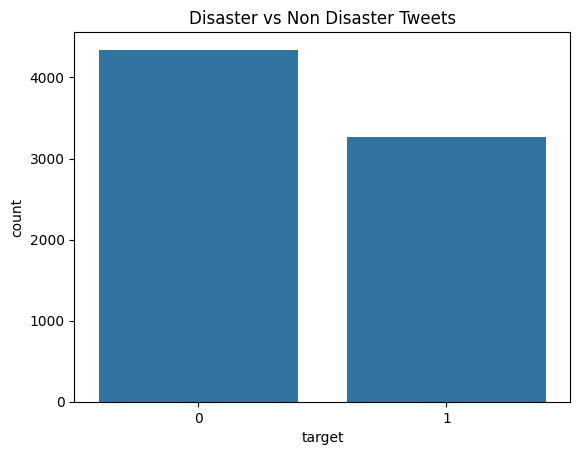

In [71]:
# Target Distribution

sns.countplot(x="target", data=df)

plt.title("Disaster vs Non Disaster Tweets")

plt.show()

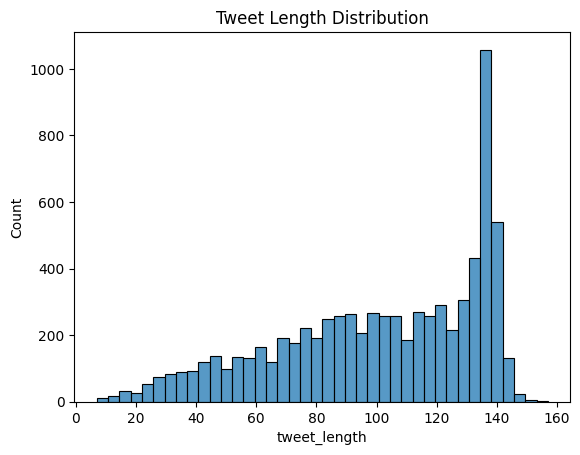

In [72]:
# Tweet Length

df["tweet_length"] = df["text"].apply(len)

sns.histplot(df["tweet_length"], bins=40)

plt.title("Tweet Length Distribution")

plt.show()

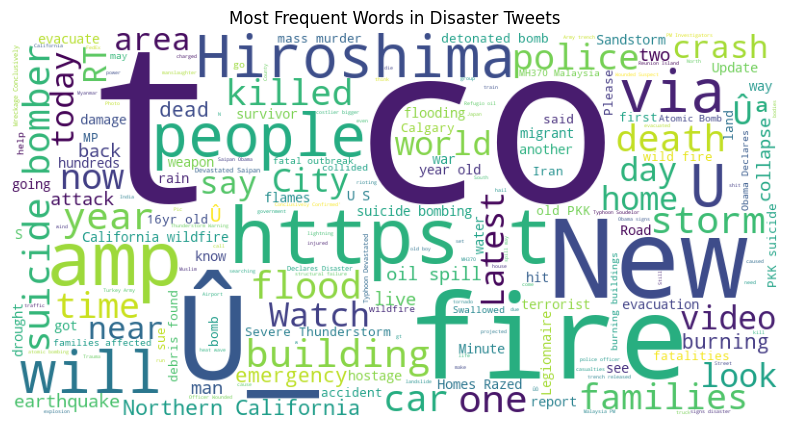

In [73]:
# WordCloud Visualization

disaster_text = " ".join(df[df["target"]==1]["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(disaster_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Disaster Tweets")

plt.show()

Text Cleaning

In [74]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r"\d+", "", text)

    return text

# Apply cleaning

df["clean_text"] = df["text"].apply(clean_text)

In [75]:
# Tokenization

df["tokens"] = df["clean_text"].apply(word_tokenize)

# Remove Stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)
# Join Tokens

df["processed_text"] = df["tokens"].apply(lambda x: " ".join(x))

Train Test Split

In [76]:
X = df["processed_text"]

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

TF-IDF Feature Engineering

In [77]:
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

Train Models

In [78]:
# Logistic Regression

lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [79]:
# Random Forest

rf = RandomForestClassifier()

rf.fit(X_train_tfidf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
# Naive Bayes

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Model Evaluation

In [81]:
lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8003939592908733
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       874
           1       0.82      0.69      0.75       649

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



In [82]:
rf_pred = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7826657912015759
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       874
           1       0.78      0.68      0.73       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



Confusion Matrix

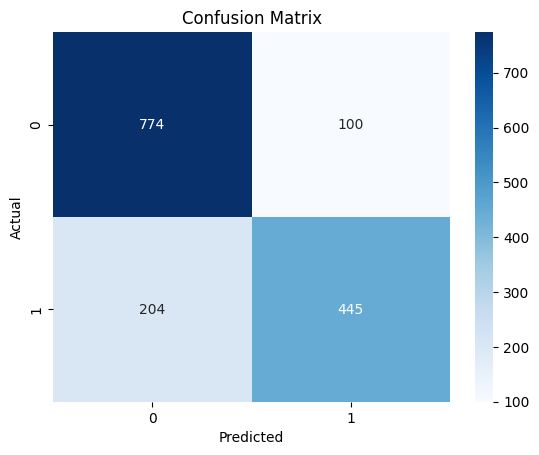

In [83]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

ROC Curve

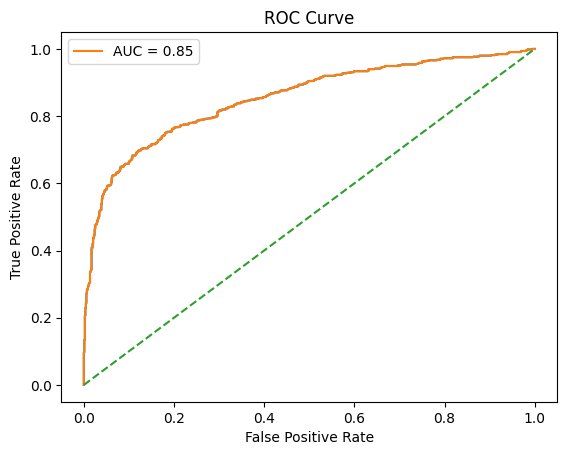

In [84]:
probs = lr.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot(fpr, tpr, label= f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Precision-Recall Curve

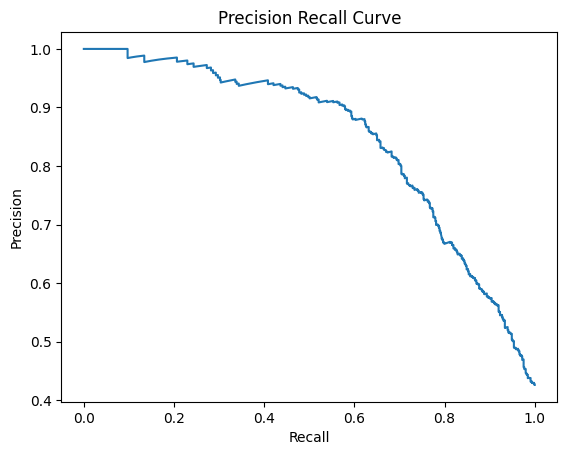

In [85]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

Save Model

In [86]:
import pickle

pickle.dump(lr, open("disaster_model.pkl","wb"))

pickle.dump(tfidf, open("tfidf_vectorizer.pkl","wb"))

Prediction Function

In [87]:
def predict_tweet(tweet):

    cleaned = clean_text(tweet)

    vect = tfidf.transform([cleaned])

    prediction = lr.predict(vect)[0]

    if prediction == 1:
        return "Disaster Tweet"
    else:
        return "Not Disaster Tweet"

In [88]:
predict_tweet("Massive earthquake hits California")

'Disaster Tweet'